## Background
The marketing team of an e-commerce site has launched an email campaign. This site has email
addresses from all the users who created an account in the past.
They have chosen a random sample of users and emailed them. The email let the user know
about a new feature implemented on the site. From the marketing team perspective, a success
is if the user clicks on the link inside of the email. This link takes the user to the company site.
You are in charge of figuring out how the email campaign performed

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc, roc_curve, classification_report,precision_score,recall_score

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2,f_classif

from sklearn.model_selection import train_test_split
import xgboost as xgb

import warnings
warnings.simplefilter('ignore')

# 1. Load Dataset

In [8]:
# import email_table.csv
df_original = pd.read_csv('email_table.csv')
df_original.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases
0,85120,short_email,personalized,2,Sunday,US,5
1,966622,long_email,personalized,12,Sunday,UK,2
2,777221,long_email,personalized,11,Wednesday,US,2
3,493711,short_email,generic,6,Monday,UK,1
4,106887,long_email,generic,14,Monday,US,6


In [9]:
df = df_original.copy()
df.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases
0,85120,short_email,personalized,2,Sunday,US,5
1,966622,long_email,personalized,12,Sunday,UK,2
2,777221,long_email,personalized,11,Wednesday,US,2
3,493711,short_email,generic,6,Monday,UK,1
4,106887,long_email,generic,14,Monday,US,6


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   email_id             100000 non-null  int64 
 1   email_text           100000 non-null  object
 2   email_version        100000 non-null  object
 3   hour                 100000 non-null  int64 
 4   weekday              100000 non-null  object
 5   user_country         100000 non-null  object
 6   user_past_purchases  100000 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 5.3+ MB


In [11]:
df.isnull().sum()

email_id               0
email_text             0
email_version          0
hour                   0
weekday                0
user_country           0
user_past_purchases    0
dtype: int64

In [12]:
df_email_opened = pd.read_csv('email_opened_table.csv')
df_email_opened

,email_id
0,284534
1,609056
2,220820
3,905936
4,164034
...,...
10340,990213
10341,918210
10342,200299
10343,211104


In [13]:
df_email_opened.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   email_id  10345 non-null  int64
dtypes: int64(1)
memory usage: 80.9 KB


In [14]:
df_email_opened.isnull().sum()

email_id    0
dtype: int64

In [15]:
df_link_clicked = pd.read_csv('link_clicked_table.csv')
df_link_clicked

,email_id
0,609056
1,870980
2,935124
3,158501
4,177561
...,...
2114,873162
2115,435454
2116,206772
2117,742967


In [16]:
df_link_clicked.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119 entries, 0 to 2118
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   email_id  2119 non-null   int64
dtypes: int64(1)
memory usage: 16.7 KB


In [17]:
df_link_clicked.isnull().sum()

email_id    0
dtype: int64

In [18]:
# check uniqueness of email_id in three tables
print('Number of unique email_id:')
print(f'    email_table.csv: {len(df['email_id'].unique())} / {len(df['email_id'])}')
print(f'    email_opened_table.csv: {len(df_email_opened['email_id'].unique())} / {len(df_email_opened['email_id'])}')
print(f'    link_clicked_table.csv: {len(df_link_clicked['email_id'].unique())} / {len(df_link_clicked['email_id'])}')

Number of unique email_id:
    email_table.csv: 100000 / 100000
    email_opened_table.csv: 10345 / 10345
    link_clicked_table.csv: 2119 / 2119


# 2. Data Processing

## 2.1 merge three tables into one


In [19]:
# 1. create a new column for df_email_opened
df_email_opened['opened'] = 1

# 2. create a new column for df_link_clicked
df_link_clicked['clicked'] = 1

# merge
df = pd.merge(left=df, right=df_email_opened, how='left', on='email_id')
df = pd.merge(left=df, right=df_link_clicked, how='left', on='email_id')

# fill NA with 0
df = df.fillna(value=0)

In [21]:
df.head()


,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases,opened,clicked
0,85120,short_email,personalized,2,Sunday,US,5,0.0,0.0
1,966622,long_email,personalized,12,Sunday,UK,2,1.0,1.0
2,777221,long_email,personalized,11,Wednesday,US,2,0.0,0.0
3,493711,short_email,generic,6,Monday,UK,1,0.0,0.0
4,106887,long_email,generic,14,Monday,US,6,0.0,0.0


In [22]:
# change 'opened' and 'clicked' columns to integer
df['opened'] = df['opened'].astype(int)
df['clicked'] = df['clicked'].astype(int)

df.head()

,email_id,email_text,email_version,hour,weekday,user_country,user_past_purchases,opened,clicked
0,85120,short_email,personalized,2,Sunday,US,5,0,0
1,966622,long_email,personalized,12,Sunday,UK,2,1,1
2,777221,long_email,personalized,11,Wednesday,US,2,0,0
3,493711,short_email,generic,6,Monday,UK,1,0,0
4,106887,long_email,generic,14,Monday,US,6,0,0


# Question 01
##### What percentage of users opened the email and what percentage clicked on the link within the email?

In [18]:
print(f"Percentage of opened the email: {df['opened'].sum()*100 / len(df)}%")
print(f"Percentage of clicked the link: {df['clicked'].sum()*100 / len(df)}%")

Percentage of opened the email: 10.345%
Percentage of clicked the link: 2.119%


# Question 02
#####  Did you find any interesting pattern on how the email campaign performed for different segments of users?

## Q2.1 EDA
EDA help us understand the data

In [19]:
# check if clicked column is balanced
clicked_dist = df['clicked'].value_counts(normalize=True)
clicked_dist

clicked
0    0.97881
1    0.02119
Name: proportion, dtype: float64

As we can see above, it is **highly imbalanced**

## Chi-Square test

Chi-Square helps us find which feature have great impact on click rate

In [23]:
from scipy.stats import chi2_contingency

df_ch2 = df.copy()

# Group past purchases into categories
df_ch2['purchase_group'] = pd.cut(
    df_ch2['user_past_purchases'],
    bins=[-1, 0, 2, 5, 10, float('inf')],
    labels=['0', '1-2', '3-5', '6-10', '11+']
)

categorical_columns = [
    'email_text',
    'email_version',
    'hour',
    'weekday',
    'user_country',
    'purchase_group'
]

results = []

for column in categorical_columns:

    # Convert categorical dtype to object so "Missing" can be added
    feature = df_ch2[column].astype(object).fillna('Missing')

    contingency_table = pd.crosstab(
        feature,
        df_ch2['clicked']
    )
    print(contingency_table)
    print("=================")

    chi2_value, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    results.append({
        'feature': column,
        'chi2_value': chi2_value,
        'p_value': p_value,
        'degrees_of_freedom': dof,
        'minimum_expected_count': expected.min()
    })

clicked          0     1
email_text              
long_email   49344   932
short_email  48537  1187
clicked            0     1
email_version             
generic        49449   760
personalized   48432  1359
clicked     0    1
hour              
1        2654   49
2        3616   60
3        4520   90
4        5531   91
5        6433  118
6        7337  128
7        8054  150
8        8239  159
9        8309  220
10       7949  231
11       7280  203
12       6341  167
13       5470  111
14       4485   95
15       3406   87
16       2695   64
17       1858   35
18       1398   23
19        890   15
20        648    8
21        362    3
22        200    4
23        139    6
24         67    2
clicked        0    1
weekday              
Friday     13978  199
Monday     14034  329
Saturday   14309  260
Sunday     14146  241
Thursday   13928  349
Tuesday    13791  352
Wednesday  13695  389
clicked           0     1
user_country             
ES             9884    83
FR             9915   

In [24]:
chi2_results = (
    pd.DataFrame(results)
    .sort_values('p_value')
    .reset_index(drop=True)
)

chi2_results

,feature,chi2_value,p_value,degrees_of_freedom,minimum_expected_count
0,purchase_group,1061.879962,1.385347e-228,4,81.64507
1,user_country,204.082662,5.533103e-44,3,211.20073
2,email_version,177.562629,1.650505e-40,1,1055.07129
3,weekday,103.230664,5.310038e-20,6,298.43996
4,hour,89.882172,7.439809e-10,23,1.46211
5,email_text,34.037432,5.406197e-09,1,1053.65156


As we can see above,
* I used a chi-square test to check whether each feature is associated with whether a user clicks. Since all p-values are far below 0.05, all six features show a statistically significant relationship with clicking.

* Purchase group shows the strongest signal, followed by country and email version. Weekday and email length are also significant. Hour appears significant too, but its minimum expected count is below 5, so I would treat that result cautiously and consider grouping hours into broader time periods.

* I would also clarify that this shows association, not causation, and I would use effect size and click-rate comparisons before ranking practical importance.


## Q2.2 Visualization

### I. Visualization of user_past_purchases
*  how many items in the past were bought by the user receiving the email

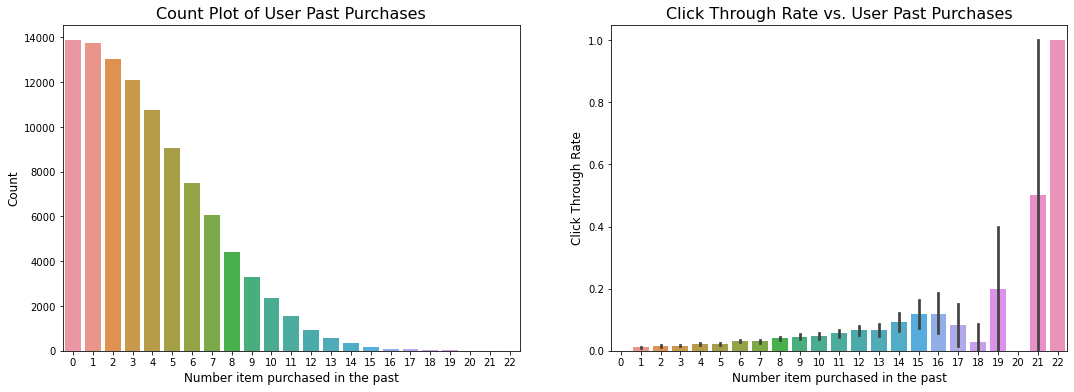

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='user_past_purchases',data=df, ax=ax[0])
ax[0].set_xlabel('Number item purchased in the past', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of User Past Purchases', fontsize=16)


sns.barplot(x='user_past_purchases', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Number item purchased in the past', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. User Past Purchases', fontsize=16)
plt.show()

In the above plots,
* the number of purchases is **positively correlated** with the click-through rate. Especially when the purchase is more than 20 times, the click-through rate increases significantly
* When the number of purchases are 17 and 18, the click-through rate decreased. Maybe because there are not enought sample size, so our company only captured this gorup of users who are unwilling to click. But we need further investigation 
* There is no any click when the number of purchases is 20, and it is very unusual. Maybe there are some technical issues prevent customers from clicking, or because the numbers of this group users are too small, so our company just happened not to send any emails to this group of users

### II. Visualization of email_version
*   Some emails were "personalized" (i.e. they had the name of the user receiving the email in the incipit, such as "Hi John,"), while some emails were "generic" (the incipit was just "Hi,").

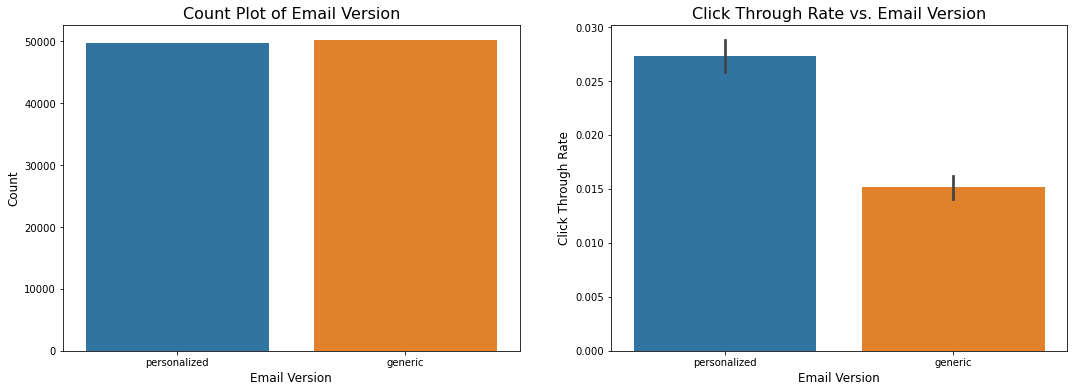

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='email_version',data=df, ax=ax[0])
ax[0].set_xlabel('Email Version', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Email Version', fontsize=16)


sns.barplot(x='email_version', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Email Version', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Email Version', fontsize=16)
plt.show()

In the above plots,
* It is clear that **personalized emails** can bring higher click-through rate

### III. Visualization of user_country
*   The country where the user receiving the email was based. It comes from the user ip address when user created the account.

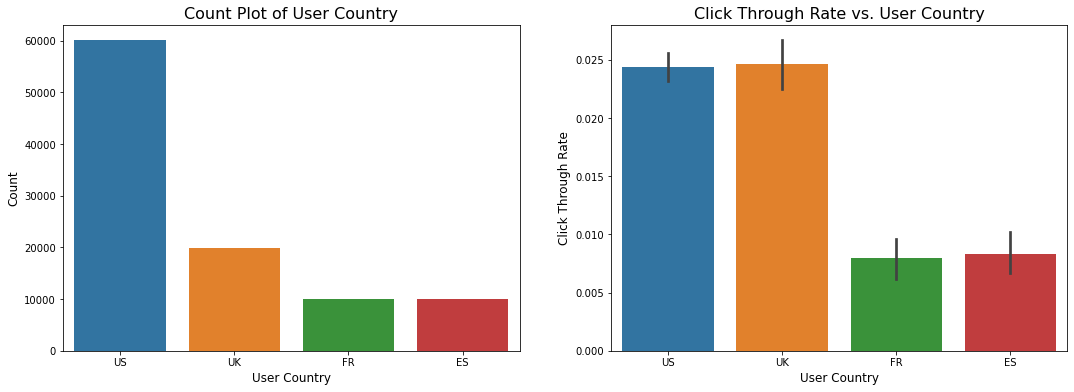

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='user_country',data=df, ax=ax[0])
ax[0].set_xlabel('User Country', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of User Country', fontsize=16)


sns.barplot(x='user_country', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('User Country', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. User Country', fontsize=16)
plt.show()

In the above plots,
* **US** and **UK** users have the highest click-through rate

### IV. Visualization of weekday
*   The day when the email was sent.

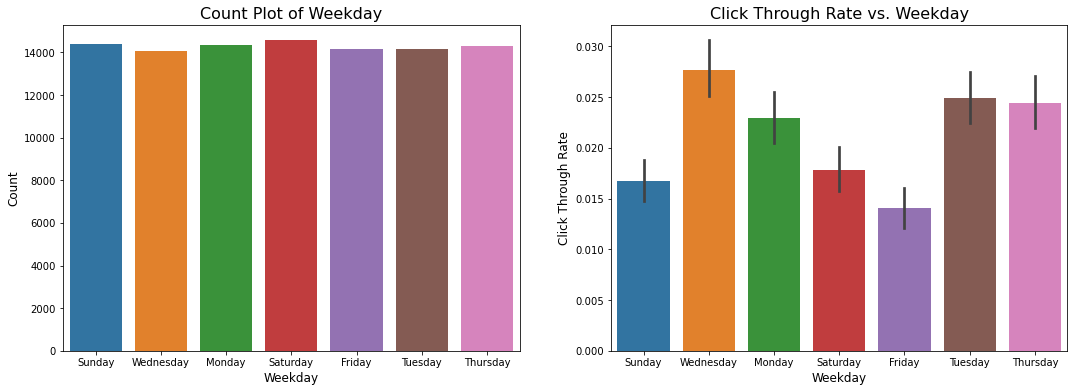

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='weekday',data=df, ax=ax[0])
ax[0].set_xlabel('Weekday', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Weekday', fontsize=16)


sns.barplot(x='weekday', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Weekday', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Weekday', fontsize=16)
plt.show()

In the above plots,
* **Wednesday** have the highest click-through rate
* The click-through rate of **Tuesday** and **Thursday** are also very high

### V. Visualization of hour
*   The user local time when the email was sent.

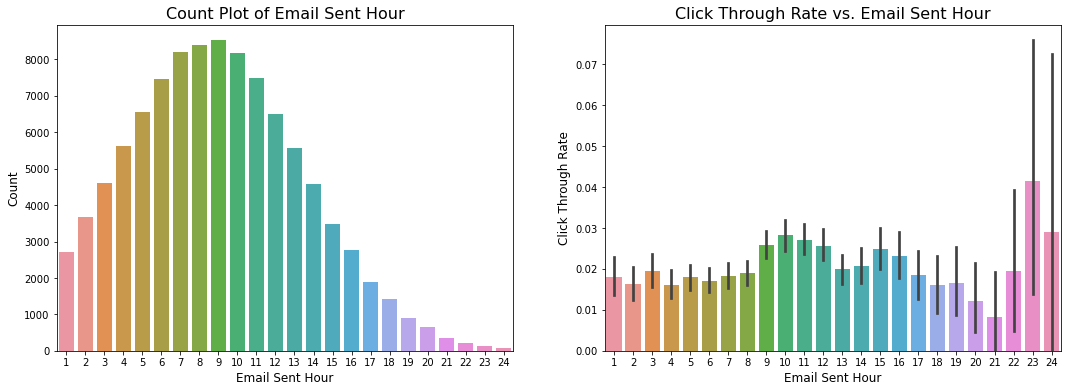

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='hour',data=df, ax=ax[0])
ax[0].set_xlabel('Email Sent Hour', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Email Sent Hour', fontsize=16)


sns.barplot(x='hour', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Email Sent Hour', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Email Sent Hour', fontsize=16)
plt.show()

In the above plots,
* When the emails are sent between **23 to 24 o'clock**, our company receives the highest click-through rate 

### VI. Visualization of email_text
*   There are two versions of the email: one has "long text" (i.e. has 4 paragraphs) and one has "short text" (just 2 paragraphs)

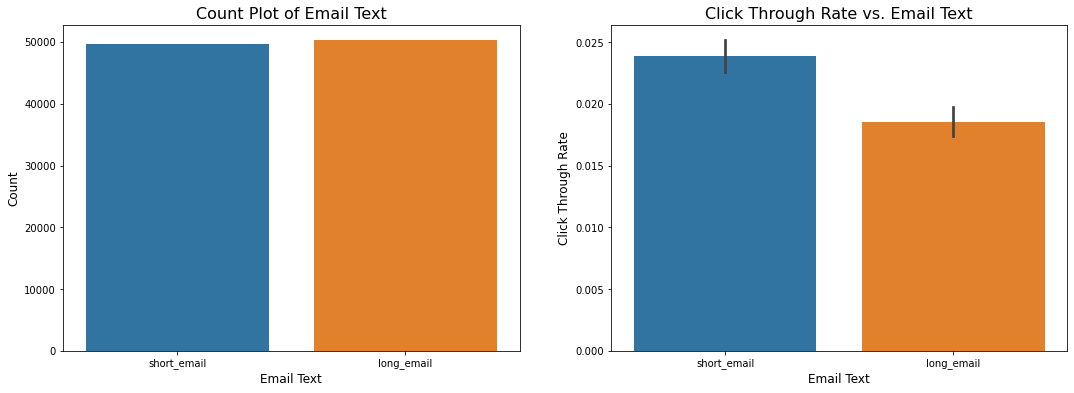

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,6))


sns.countplot(x='email_text',data=df, ax=ax[0])
ax[0].set_xlabel('Email Text', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Count Plot of Email Text', fontsize=16)


sns.barplot(x='email_text', y='clicked',data=df, ax=ax[1])
ax[1].set_xlabel('Email Text', fontsize=12)
ax[1].set_ylabel('Click Through Rate', fontsize=12)
ax[1].set_title('Click Through Rate vs. Email Text', fontsize=16)
plt.show()

In the above plots,
* It is clear that **"short text" email** can bring higher click-through rate

# Question 03
* Based on all the information you have about the emails that were sent, can you build a model to optimize in future email campaigns to maximize the probability of users clicking on the link inside the email?


## ML Model
We will use XGBoost.

Below is a cleaner end-to-end version that keeps the useful ideas from your original code:

Separate training, validation, and test sets
One-hot encoding with pd.get_dummies()
Stratified splitting
Validation-based early stopping
Threshold selection on validation data only
Final test evaluation
ROC-AUC, average precision, confusion matrix, and classification report
Gain-based feature importance

I recommend XGBClassifier here instead of manually creating DMatrix objects. Current XGBoost estimators automatically use best_iteration for predict() and predict_proba() after early stopping, so ntree_limit is no longer needed.

## 3.1 XGBoost Model code

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    roc_auc_score
)


In [5]:
# ============================================================
# 1. Configuration
# ============================================================

RANDOM_STATE = 11
TARGET_COLUMN = "clicked"

# opened is intentionally excluded because it happens after
# the email is sent and could cause data leakage.
FEATURE_COLUMNS = [
    "email_text",
    "email_version",
    "hour",
    "weekday",
    "user_country",
    "user_past_purchases"
]

CATEGORICAL_COLUMNS = [
    "email_text",
    "email_version",
    "hour",
    "weekday",
    "user_country"
]

NUMERIC_COLUMNS = [
    "user_past_purchases"
]



In [23]:
# ============================================================
# 2. Basic data validation
# ============================================================

required_columns = set(FEATURE_COLUMNS + [TARGET_COLUMN])
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"The dataframe is missing these columns: {sorted(missing_columns)}"
    )


model_data = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()

# Remove rows where the target is missing
model_data = model_data.dropna(subset=[TARGET_COLUMN])

X = model_data[FEATURE_COLUMNS].copy()
y = model_data[TARGET_COLUMN].astype(int).copy()

if not set(y.unique()).issubset({0, 1}):
    raise ValueError("The clicked target must contain only 0 and 1.")

print("Dataset shape:", model_data.shape)
print("Overall click rate:", round(y.mean(), 4))
print("\nTarget counts:")
print(y.value_counts())

Dataset shape: (100000, 7)
Overall click rate: 0.0212

Target counts:
clicked
0    97881
1     2119
Name: count, dtype: int64


In [24]:
# ============================================================
# 3. Create train, validation, and test sets
#
# 70% training
# 15% validation
# 15% test
# ============================================================

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("\nSplit sizes:")
print("Training:", X_train_raw.shape)
print("Validation:", X_valid_raw.shape)
print("Test:", X_test_raw.shape)

print("\nClick rates:")
print("Training:", round(y_train.mean(), 4))
print("Validation:", round(y_valid.mean(), 4))
print("Test:", round(y_test.mean(), 4))


Split sizes:
Training: (70000, 6)
Validation: (15000, 6)
Test: (15000, 6)

Click rates:
Training: 0.0212
Validation: 0.0212
Test: 0.0212


In [26]:
# ============================================================
# 4. Handle missing values
#
# Numeric replacement values must be calculated from the
# training set only.
# ============================================================

numeric_fill_values = X_train_raw[NUMERIC_COLUMNS].median()


def clean_features(frame):
    """
    Handle categorical and numeric missing values without
    modifying the original dataframe.
    """
    cleaned = frame.copy()

    # Convert categorical columns to strings and represent
    # missing values as their own category.
    for column in CATEGORICAL_COLUMNS:
        cleaned[column] = (
            cleaned[column]
            .astype("string")
            .fillna("Missing")
        )

    # Use medians calculated from training data only
    cleaned[NUMERIC_COLUMNS] = (
        cleaned[NUMERIC_COLUMNS]
        .fillna(numeric_fill_values)
    )

    return cleaned


X_train_clean = clean_features(X_train_raw)
X_valid_clean = clean_features(X_valid_raw)
X_test_clean = clean_features(X_test_raw)

In [27]:
# ============================================================
# 5. One-hot encode categorical features
#
# Only the training columns define the final model schema.
# Unknown validation/test categories become all zeros.
# ============================================================

X_train = pd.get_dummies(
    X_train_clean,
    columns=CATEGORICAL_COLUMNS,
    dtype=np.int8,
    drop_first=False
)

X_valid = pd.get_dummies(
    X_valid_clean,
    columns=CATEGORICAL_COLUMNS,
    dtype=np.int8,
    drop_first=False
)

X_test = pd.get_dummies(
    X_test_clean,
    columns=CATEGORICAL_COLUMNS,
    dtype=np.int8,
    drop_first=False
)

# Ensure validation and test have exactly the same columns
# and column order as training.
X_valid = X_valid.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("\nNumber of encoded features:", X_train.shape[1])
print("Matching validation columns:", X_valid.columns.equals(X_train.columns))
print("Matching test columns:", X_test.columns.equals(X_train.columns))


Number of encoded features: 40
Matching validation columns: True
Matching test columns: True


In [28]:
# ============================================================
# 6. Optional class weighting
#
# XGBoost documents negative / positive as a typical starting
# value for scale_pos_weight when classes are imbalanced.
# ============================================================

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

if positive_count == 0:
    raise ValueError("The training set contains no clicked examples.")

class_ratio = negative_count / positive_count

# Set to False when well-calibrated probabilities matter more
# than emphasizing the minority class.
USE_CLASS_WEIGHT = True

scale_pos_weight = class_ratio if USE_CLASS_WEIGHT else 1.0

print("\nNegative-to-positive ratio:", round(class_ratio, 3))
print("scale_pos_weight:", round(scale_pos_weight, 3))


Negative-to-positive ratio: 46.202
scale_pos_weight: 46.202


In [29]:
# ============================================================
# 7. Define the XGBoost model
#
# These are reasonable starting values, not guaranteed optimal
# hyperparameters.
# ============================================================

model = xgb.XGBClassifier(
    objective="binary:logistic",

    # Useful model-selection metric when clicks are uncommon
    eval_metric="aucpr",

    # Large upper limit; early stopping chooses the useful number
    n_estimators=3000,
    early_stopping_rounds=50,

    # Learning parameters
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    gamma=0,

    # Row and feature sampling
    subsample=0.80,
    colsample_bytree=0.80,

    # Regularization
    reg_alpha=0.0,
    reg_lambda=1.0,

    # Class imbalance
    scale_pos_weight=scale_pos_weight,

    # Efficient tree-building method
    tree_method="hist",

    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [30]:
# ============================================================
# 8. Train with early stopping
#
# Validation must be last in eval_set because it controls
# early stopping.
# ============================================================

model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_valid, y_valid)
    ],
    verbose=100
)

print("\nBest iteration:", model.best_iteration)
print("Best validation score:", model.best_score)
print("Best number of trees:", model.best_iteration + 1)

[0]	validation_0-aucpr:0.04937	validation_1-aucpr:0.04175
[100]	validation_0-aucpr:0.07051	validation_1-aucpr:0.05882
[155]	validation_0-aucpr:0.07597	validation_1-aucpr:0.05732

Best iteration: 105
Best validation score: 0.05910276632820879
Best number of trees: 106


## 3.2 Select a classification threshold

Your old threshold, 0.026351, should not be hard-coded for a new model. Choose the threshold using the validation set.

This version keeps your original business idea: achieve at least 60% recall, then choose the threshold with the best precision among those options.

A precision-recall curve calculates precision and recall across different probability thresholds.

In [31]:
# ============================================================
# 9. Select threshold using validation data only
# ============================================================

def choose_threshold_for_minimum_recall(
    y_true,
    probabilities,
    minimum_recall=0.60
):
    """
    Among thresholds that achieve at least minimum_recall,
    select the threshold with the highest precision.
    """
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probabilities
    )
    print(f'{precision=}')
    print(f'{recall=}')
    print(f'{thresholds=}')
    # The final precision and recall entries do not have a
    # corresponding threshold.
    precision = precision[:-1]
    recall = recall[:-1]

    eligible_indices = np.flatnonzero(
        recall >= minimum_recall
    )

    if len(eligible_indices) == 0:
        raise ValueError(
            f"No threshold achieved recall >= {minimum_recall:.2f}"
        )

    best_index = eligible_indices[
        np.argmax(precision[eligible_indices])
    ]

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(precision[best_index]),
        "recall": float(recall[best_index])
    }


valid_probabilities = model.predict_proba(X_valid)[:, 1]

threshold_result = choose_threshold_for_minimum_recall(
    y_true=y_valid,
    probabilities=valid_probabilities,
    minimum_recall=0.60
)

selected_threshold = threshold_result["threshold"]
print("===================")
print("\nSelected validation threshold:")
print("Threshold:", round(selected_threshold, 6))
print("Precision:", round(threshold_result["precision"], 4))
print("Recall:", round(threshold_result["recall"], 4))

precision=array([0.0212    , 0.02120141, 0.02120283, ..., 0.5       , 1.        ,
       1.        ])
recall=array([1.        , 1.        , 1.        , ..., 0.00314465, 0.00314465,
       0.        ])
thresholds=array([0.00706153, 0.00750591, 0.00834975, ..., 0.87734866, 0.8821618 ,
       0.895512  ], dtype=float32)

Selected validation threshold:
Threshold: 0.545991
Precision: 0.0418
Recall: 0.6006


## 3.3 Evaluation function
The classification report summarizes precision, recall, F1, and support for each class.

In [32]:
# ============================================================
# 10. Evaluation function
# ============================================================

def evaluate_predictions(
    dataset_name,
    y_true,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)
    print(f"{predictions=}")

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    average_precision = average_precision_score(
        y_true,
        probabilities
    )

    print("\n" + "=" * 60)
    print(dataset_name)
    print("=" * 60)

    print("Threshold:", round(threshold, 6))
    print("Actual click rate:", round(y_true.mean(), 4))
    print("Predicted positive rate:", round(predictions.mean(), 4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("Average precision:", round(average_precision, 4))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, predictions))

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            predictions,
            target_names=["not_clicked", "clicked"],
            digits=4,
            zero_division=0
        )
    )

    return {
        "probabilities": probabilities,
        "predictions": predictions,
        "roc_auc": roc_auc,
        "average_precision": average_precision
    }


# Validation evaluation
validation_results = evaluate_predictions(
    dataset_name="Validation results",
    y_true=y_valid,
    probabilities=valid_probabilities,
    threshold=selected_threshold
)


predictions=array([0, 1, 0, ..., 1, 0, 1])

Validation results
Threshold: 0.545991
Actual click rate: 0.0212
Predicted positive rate: 0.3045
ROC-AUC: 0.7339
Average precision: 0.0598

Confusion matrix:
[[10306  4376]
 [  127   191]]

Classification report:
              precision    recall  f1-score   support

 not_clicked     0.9878    0.7019    0.8207     14682
     clicked     0.0418    0.6006    0.0782       318

    accuracy                         0.6998     15000
   macro avg     0.5148    0.6513    0.4495     15000
weighted avg     0.9678    0.6998    0.8050     15000



Here is exactly how your numbers break down for your click prediction data:

|  | Predicted: NO CLICK | Predicted: CLICK |
| --- | --- | --- |
| **Actual: NO CLICK** | **10,306** (True Negative) | **4,376** (False Positive) |
| **Actual: CLICK** | **127** (False Negative) | **191** (True Positive) |

#### **The 4 Quadrants Explained**

- **10,306 (True Negatives)**: The model predicted these users would not click, and they didn't. This is your biggest group because most users don't click links.
- **4,376 (False Positives / False Alarms)**: The model predicted these users *would* click, but they actually did not. This is why your precision is low (4.18%).
- **127 (False Negatives / Misses)**: The model predicted these users would ignore the link, but they actually *did* click it. These are your missed opportunities.
- **191 (True Positives / Hits)**: The model predicted these users would click, and they successfully did.

===============
- **Your Baseline CTR (2.12%)**: There were **318 total actual clickers** ($191 + 127$) out of **15,000 total users**.
- **Your Recall (60.06%)**: Out of those 318 real clickers, your model successfully caught **191** of them ($\frac{191}{318}$).
- **Your Precision (4.18%)**: The model sent out **4,567 total click predictions** ($191 + 4376$), but only **191** actually turned into real clicks ($\frac{191}{4567}$).



=====================
##### **Classification Report**
##### **👤 The Class Breakdown (Rows 1 & 2)**

###### **1. `not_clicked` (The Majority Group)**

The model is incredibly good at identifying people who **won't** click because there are so many of them in your data.

- **Precision (0.9878)**: When the model predicts someone will *not* click, it is right **98.78%** of the time. You can highly trust its "No" predictions.
- **Recall (0.7019)**: The model successfully found **70.19%** of all the people who actually didn't click. It accidentally grouped the other 29.81% into the "clicked" category (your False Positives).
- **Support (14,682)**: There are 14,682 actual "no click" users in your evaluation dataset.

##### **2. `clicked` (The Rare Target Group)**

This matches the exact metrics we discussed earlier.

- **Precision (0.0418)**: When it predicts a click, it is only right **4.18%** of the time.
- **Recall (0.6006)**: It successfully caught **60.06%** of all actual clickers.
- **F1-Score (0.0782)**: This balances precision and recall into a single score from 0 to 1. Because your precision is so close to zero, your F1-score for this class is very low (**0.0782**).
- **Support (318)**: There are only 318 actual clickers in your dataset.

---

##### **📊 The Global Averages (The Bottom Rows)**

##### **3. `accuracy` (0.6998)**

Overall, the model guessed correctly **69.98%** of the time across the entire dataset.

- *Warning*: Do not use this to judge your model! Because 98% of your data is `not_clicked`, a high accuracy score here is misleading. It is driven entirely by the model guessing the "No" class correctly. [3]

##### **4. `macro avg`**

This calculates the simple average of your two classes, treating them as equally important regardless of size. [4, 5]

- **Macro Precision**: $(0.9878 + 0.0418) / 2 = \mathbf{0.5148}$
- **Use Case**: This score is purposefully low here to punish the model for performing poorly on the rare `clicked` class. It tells you your model is highly unbalanced. [6]

##### **5. `weighted avg`**

This calculates the average but weights it based on the `support` (size) of each class. [7, 8, 9, 10]

- **Weighted Precision**: Since 14,682 out of 15,000 users are `not_clicked`, the overall weighted precision $(\mathbf{0.9678})$ looks beautifully high because it is heavily skewed by the easy-to-predict majority class.


##### **🔄 The Precision Formula & Calculation**

- **The Formula:**$$\text{Weighted Precision} = \frac{(\text{Precision}_{\text{not\_clicked}} \times 14682) + (\text{Precision}_{\text{clicked}} \times 318)}{15000}$$
- **Inserting the Numbers:**$$\text{Weighted Precision} = \frac{(0.9878 \times 14682) + (0.0418 \times 318)}{15000}$$
- **Step-by-Step Math:**$$\text{Weighted Precision} = \frac{14502.8796 + 13.2924}{15000}$$ $$\text{Weighted Precision} = \frac{14516.172}{15000}$$ $$\mathbf{\text{Result}} \approx \mathbf{0.9678}$$

##### **🔄 Weighted Recall Formula & Calculation**

- **The Formula:**$$\text{Weighted Recall} = \frac{(\text{Recall}_{\text{not\_clicked}} \times 14682) + (\text{Recall}_{\text{clicked}} \times 318)}{15000}$$
- **Inserting the Numbers:**$$\text{Weighted Recall} = \frac{(0.7019 \times 14682) + (0.6006 \times 318)}{15000}$$
- **Step-by-Step Math:**$$\text{Weighted Recall} = \frac{10305.2958 + 191.0108}{15000}$$ $$\text{Weighted Recall} = \frac{10496.3066}{15000}$$ $$\mathbf{\text{Result}} \approx \mathbf{0.6998}$$


##### **🔄 Weighted F1-Score Formula & Calculation**

- **The Formula:**$$\text{Weighted F1-Score} = \frac{(\text{F1}_{\text{not\_clicked}} \times 14682) + (\text{F1}_{\text{clicked}} \times 318)}{15000}$$
- **Inserting the Numbers:**$$\text{Weighted F1-Score} = \frac{(0.8207 \times 14682) + (0.0782 \times 318)}{15000}$$
- **Step-by-Step Math:**$$\text{Weighted F1-Score} = \frac{12049.5174 + 24.8676}{15000}$$ $$\text{Weighted F1-Score} = \frac{12074.385}{15000}$$ $$\mathbf{\text{Result}} \approx \mathbf{0.8050}$$

In [33]:
# ============================================================
# 11. Final test evaluation
#
# Do this only after model and threshold decisions are complete.
# ============================================================

test_probabilities = model.predict_proba(X_test)[:, 1]

test_results = evaluate_predictions(
    dataset_name="Final test results",
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=selected_threshold
)

predictions=array([1, 0, 1, ..., 0, 1, 0])

Final test results
Threshold: 0.545991
Actual click rate: 0.0212
Predicted positive rate: 0.2958
ROC-AUC: 0.7446
Average precision: 0.0559

Confusion matrix:
[[10445  4237]
 [  118   200]]

Classification report:
              precision    recall  f1-score   support

 not_clicked     0.9888    0.7114    0.8275     14682
     clicked     0.0451    0.6289    0.0841       318

    accuracy                         0.7097     15000
   macro avg     0.5170    0.6702    0.4558     15000
weighted avg     0.9688    0.7097    0.8117     15000



## 3.4 ROC and precision-recall curves

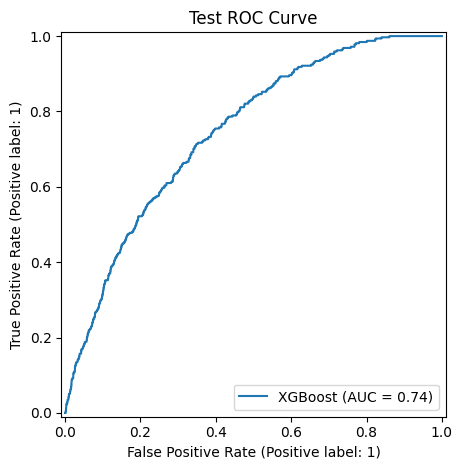

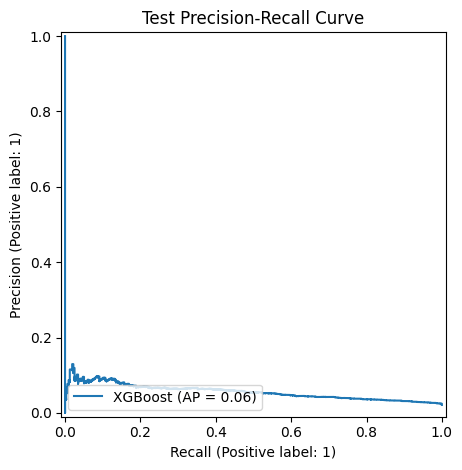

In [34]:
# ============================================================
# 12. Evaluation curves
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="XGBoost"
)

plt.title("Test ROC Curve")
plt.tight_layout()
plt.show()


PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="XGBoost"
)

plt.title("Test Precision-Recall Curve")
plt.tight_layout()
plt.show()

##### **1. Test ROC Curve (The Optimistic View)**

This chart plots the **True Positive Rate** (Recall, y-axis) against the **False Positive Rate** (False alarms out of all non-clickers, x-axis).

- **The Goal**: A perfect model hugs the top-left corner. A completely random, useless model is a straight diagonal line from bottom-left to top-right ($\text{AUC} = 0.50$).
- **Area Under the Curve (AUC = 0.74)**: A score of `0.74` means the model has a **74% chance** of correctly ranking a real clicker higher than a non-clicker. This is generally considered a "fair to good" score.
- **How to read it**: It shows the model is successfully learning patterns and is significantly better than random guessing.
 
---

##### **2. Test Precision-Recall Curve <Average Precision (AP) = PR-AUC>**

This chart plots **Precision** (y-axis) against **Recall** (x-axis).

- **The Goal**: A perfect model stays at the top-right corner ($1.0$ precision and $1.0$ recall).
- **Average Precision (AP = 0.06)**: This is the average precision across all thresholds. A score of `0.06` is low, but remember your baseline random guessing rate is only `0.02` (2%).
- **How to read it**: Look at `0.6` on the bottom line (Recall). Go up to the blue line, then look left to see the Precision. You will see it sits right around `0.04`—exactly the lopsided result from your classification report. It shows that the moment you try to catch more than 20% of clickers, your precision plummets close to zero.


---

##### **💡 Why do they look so different?**

This is a classic machine learning paradox.

The **ROC curve looks good** because its x-axis (False Positive Rate) divides your 4,376 false alarms by the massive pool of 14,682 non-clickers ($\frac{4376}{14682} \approx 30\%$). This makes the error rate look small.

The **PR curve looks bad** because its y-axis (Precision) divides your 191 true hits by those same 4,376 false alarms ($\frac{191}{191+4376} \approx 4.18\%$). Because real clicks are so rare, the false alarms completely overwhelm your true hits.

**Conclusion**: For predicting rare events like user clicks, **always trust the Precision-Recall curve** over the ROC curve to judge real-world business performance.

## 3.5 Feature importance
Use gain rather than the default split-count importance.

Remember that one-hot encoding produces category-level importance:

* email_version_personalized
* email_version_generic
* user_country_US
* user_country_UK
* weekday_Monday
* hour_12

Therefore, the chart ranks individual categories, not necessarily the complete original feature.

{'user_past_purchases': 415.015869140625, 'email_text_long_email': 106.73695373535156, 'email_text_short_email': 73.73558807373047, 'email_version_generic': 221.55050659179688, 'email_version_personalized': 197.1902313232422, 'hour_1': 70.86882781982422, 'hour_10': 82.54583740234375, 'hour_11': 97.65583801269531, 'hour_12': 74.95008850097656, 'hour_13': 51.1181755065918, 'hour_14': 78.63849639892578, 'hour_15': 40.987361907958984, 'hour_16': 38.58408737182617, 'hour_17': 68.98961639404297, 'hour_18': 68.49991607666016, 'hour_19': 58.7401237487793, 'hour_2': 90.8160400390625, 'hour_20': 84.66940307617188, 'hour_21': 84.67366027832031, 'hour_22': 71.41886138916016, 'hour_23': 64.94945526123047, 'hour_24': 25.970754623413086, 'hour_3': 93.45445251464844, 'hour_4': 84.45004272460938, 'hour_5': 89.40731811523438, 'hour_6': 67.55740356445312, 'hour_7': 71.21722412109375, 'hour_8': 80.30792236328125, 'hour_9': 79.64125061035156, 'weekday_Friday': 122.21163177490234, 'weekday_Monday': 64.72706

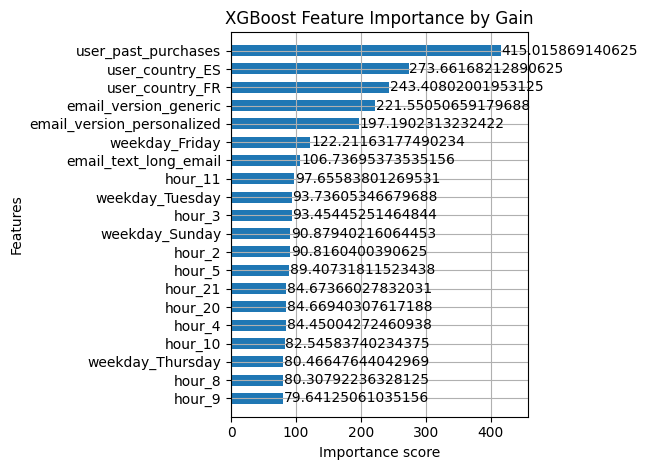

In [36]:
# ============================================================
# 13. Feature importance by gain
# ============================================================

booster = model.get_booster()

importance_dictionary = booster.get_score(
    importance_type="gain"
)
print(f"{importance_dictionary}")
importance_df = (
    pd.DataFrame(
        importance_dictionary.items(),
        columns=["feature", "gain"]
    )
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

print("\nTop features by gain:")
print(importance_df.head(20))


xgb.plot_importance(
    booster,
    importance_type="gain",
    max_num_features=20,
    height=0.6
)

plt.title("XGBoost Feature Importance by Gain")
plt.tight_layout()
plt.show()

## 3.6 Save the model and preprocessing information
JSON or UBJSON preserves XGBoost model information such as feature names.

In [38]:
# ============================================================
# 14. Save model and preprocessing metadata
# ============================================================
saved_model_file_name = 'xgboost_click_model'

model.save_model(f"{saved_model_file_name}.json")

preprocessing_metadata = {
    "raw_feature_columns": FEATURE_COLUMNS,
    "categorical_columns": CATEGORICAL_COLUMNS,
    "numeric_columns": NUMERIC_COLUMNS,
    "encoded_feature_columns": X_train.columns.tolist(),
    "numeric_fill_values": numeric_fill_values.to_dict(),
    "classification_threshold": selected_threshold
}

print(f"\nModel saved as: {saved_model_file_name}.json")


Model saved as: xgboost_click_model.json


## 3.7 Summary:
### Simple rule to measure which model is better
To cut through the noise of all these numbers, you only need to focus on **one global metric** to pick the best model, and **one operational metric** to run your business.

Because your click data is heavily imbalanced, you can completely ignore Accuracy, ROC-AUC, and all Weighted Averages.

Here is the simple, two-step rule to always know which model is better:

#### Rule 1: Use "Average Precision" (AP) to pick the winning model

When comparing Model A vs. Model B, look **only** at Average Precision (or PR-AUC).

- **The Rule**: The model with the higher Average Precision is the mathematically superior model. Period.
- **Why**: It evaluates the model across *all* possibilities. It proves which model is actually smarter at ranking potential clickers at the top, completely independent of whatever temporary threshold you chose.

#### Rule 2: Use the "Clicked F1-Score" to pick the best setting

Once you have picked the winning model using Rule 1, look at the **`clicked` row** in your classification report to find the best operational setting (threshold).

- **The Rule**: Look exclusively at the **F1-score for the `clicked` class**. The threshold that maximizes this specific number gives you the best real-world balance between catching clickers and avoiding false alarms.
- **Why**: The F1-score mathematically crashes if your precision is terrible or if your recall is terrible. It forces a healthy compromise.

---

#### 💡 Cheat Sheet Summary

Whenever you train new models, put them through this simple filter:

1. **Which model is inherently better?** $\rightarrow$ Look at **Average Precision (AP)**.
2. **Which target group matters?** $\rightarrow$ Look only at the **`clicked` row** metrics.
3. **Is the balance right?** $\rightarrow$ Look at the **`clicked` F1-score**.
4. **What can I ignore?** $\rightarrow$ Ignore **Accuracy**, **ROC-AUC**, and **Weighted Averages**.

Using this rule for your data, your **old model** was the better model (higher AP), but your **new model setup** accidentally had a better F1-score simply because it used a tighter threshold.

### Main improvements over your original code

1. `XGBClassifier` replaces manual `DMatrix` management.
2. `eval_metric="aucpr"` replaces the incorrect `params["metric"]`.
3. `n_estimators` and `early_stopping_rounds` are model controls, not entries such as `num_rounds` inside a booster parameter dictionary.
4. `ntree_limit` is removed.
5. The data is split using `stratify=y`.
6. Validation controls early stopping and threshold selection.
7. The test set is reserved for the final evaluation.
8. The threshold is calculated rather than hard-coded.
9. Both ROC-AUC and average precision are reported.
10. Feature importance uses `gain`, not just split frequency.

One caution: enabling `scale_pos_weight` helps emphasize the rare clicked class, and XGBoost documents the negative-to-positive ratio as a common starting value. However, class weighting can make the raw outputs less suitable as literal click-probability estimates. Keep it enabled when ranking users or improving click recall is the priority; disable it when probability calibration is the main objective.

# Question 04
* By how much do you think your model would improve click through rate ( defined as # of users who click on the link / total users who received the email). How would you test that?

In [49]:
print(f"The new click through rate: {precision_score(y_test,y_test_pred) * 100:.1f}%")

The new click through rate: 4.1%


* Answer: The new click through rate is 4.1%. Compare with the old click through rate (2.12%) , the new click through rate is creased **1.98%**

##### How would you test that?

To test my conclusion, we need to perform a A/B test:

1. Randomly assign users to two groups, Control group and Experiment group.
2. In Control group, still use the old email-campaign strategy, i.e., just send emails to all users in Control group.
3. In Experiment group, use my model to predict whether the user will click the link or not. and only send emails to those users whose predictive result is positive.
4. Then we preform a one-tail unpaired t-test to test whether Experiement group's click through rate is higher than Control group's click through rate.